## Word Embeddings

→ In NLP, **word embedding** is a term used for the representation of words for text analysis, typically in the form of a real-valued vector that encodes the meaning of words such that words that are closer in the vector space are expected to be similar in meaning.


#### Types of Word Embeddings

**Frequency-based** → Based on word frequency counts.
Examples: **BoW (Bag of Words)**, **TF-IDF (Term Frequency–Inverse Document Frequency)**, **GloVe (Global Vectors for Word Representation)**

**Prediction-based** → Based on algorithm predictions (context-based learning).
Examples: **Word2Vec**



### Word2Vec

→ **Word2Vec** is a word embedding technique whose job is to convert given words into vectors (i.e., a collection of numbers).

→ **Why is it needed?**
Because we cannot directly use or process raw words in machine learning models. Models understand numbers, not text.

→ It was developed by engineers at **Google**.

---

### What is different from older embedding techniques?

**1) Captures semantic meaning**

* In older techniques like **BoW** and **TF-IDF**, the model cannot understand that words like *“happy”* and *“joy”* are similar.
* **Word2Vec** can capture this similarity because words that appear in similar contexts get similar vector representations.

**2) Learns semantic relationships**

* It captures the meaning of words based on context.
* Example: *king – man + woman ≈ queen* (semantic relationship).

**3) Lower dimensional vectors**

* In **BoW** and **TF-IDF**, vectors are very high-dimensional (sometimes 10,000+ dimensions).
* In **Word2Vec**, vectors are low-dimensional (usually around 100–300 dimensions).
* This reduces computational cost and increases speed.

**4) Dense vectors**

* **Word2Vec** produces **dense vectors** (most values are non-zero).
* **BoW** and **TF-IDF** produce **sparse vectors** (most values are zero).

---

### in one shot

Word2Vec is better than older techniques because it captures semantic meaning, produces smaller dense vectors, and improves computational efficiency.


#### We can work in 2 ways

→ **1) Use a pre-trained model**
We can use a model that is already trained on a large dataset.
This saves time and computational cost.

→ **2) Train on our own dataset (self-trained model)**
We can train Word2Vec on our own custom dataset if we want domain-specific word meanings.


#### For Demo Purpose

We will use the **pre-trained weights of Word2Vec** that were trained on the **Google News corpus**, which contains around **100 billion words**.

This pre-trained model consists of **300-dimensional vectors** for **3 million words and phrases**.

Using this model helps us avoid training from scratch and allows us to directly work with high-quality word embeddings for demonstration purposes.

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.7 MB/s eta 0:00:00


In [2]:
import gensim
from gensim.models import Word2Vec,KeyedVectors

In [3]:
import gensim.downloader as api

# Downloads once, then cached for future sessions
model = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [4]:
model

In [5]:
model["car"].shape

(300,)

In [6]:
model["home"]

array([-0.01184082,  0.07958984,  0.0168457 , -0.08984375,  0.08642578,
        0.02416992,  0.0255127 , -0.18945312,  0.14160156,  0.08447266,
        0.16992188, -0.25      , -0.0534668 , -0.02832031,  0.04541016,
       -0.14746094,  0.01226807,  0.05639648,  0.01953125,  0.21582031,
        0.15722656, -0.15917969,  0.08837891, -0.10595703, -0.00408936,
       -0.02331543, -0.04931641,  0.08154297,  0.03808594,  0.00177002,
        0.05517578,  0.03735352, -0.14648438, -0.03808594, -0.05517578,
        0.01135254, -0.07861328, -0.14941406,  0.09033203,  0.03710938,
        0.08837891, -0.01483154,  0.18261719,  0.09667969, -0.05517578,
        0.16308594,  0.03955078,  0.1640625 ,  0.08398438,  0.0279541 ,
       -0.03442383,  0.296875  ,  0.140625  ,  0.09863281, -0.18457031,
       -0.26367188, -0.12109375,  0.18261719,  0.02282715, -0.04248047,
       -0.02062988,  0.08251953, -0.00140381,  0.02246094, -0.07617188,
        0.02709961, -0.04711914,  0.05639648, -0.00250244,  0.11

In [8]:
model.most_similar("man")

[('woman', 0.7664012908935547),
 ('boy', 0.6824871301651001),
 ('teenager', 0.6586930155754089),
 ('teenage_girl', 0.6147903203964233),
 ('girl', 0.5921714305877686),
 ('suspected_purse_snatcher', 0.571636438369751),
 ('robber', 0.5585119128227234),
 ('Robbery_suspect', 0.5584409832954407),
 ('teen_ager', 0.5549196600914001),
 ('men', 0.5489763021469116)]

In [9]:
model.most_similar("plane")

[('airplane', 0.8348400592803955),
 ('jet', 0.7661097049713135),
 ('planes', 0.7439613938331604),
 ('aircraft', 0.7360518574714661),
 ('jetliner', 0.7206447124481201),
 ('airliner', 0.7167277932167053),
 ('Cessna', 0.6842411160469055),
 ('Plane', 0.6765829920768738),
 ('propeller_plane', 0.6752769351005554),
 ('flight', 0.6747332215309143)]

In [10]:
model.most_similar("youtube")

[('Youtube', 0.7923596501350403),
 ('youtube.com', 0.6960442066192627),
 ('vid', 0.666364312171936),
 ('YouTube', 0.6590824127197266),
 ('vids', 0.620431125164032),
 ('YouTube.com', 0.6139892339706421),
 ('UTube', 0.6135973334312439),
 ('vimeo', 0.6086797118186951),
 ('Utube', 0.6068244576454163),
 ('utube', 0.605649471282959)]

In [11]:
model.similarity("man","woman")

np.float32(0.76640123)

In [13]:
model.similarity("cricket","code")

np.float32(0.13164535)

In [16]:
model.doesnt_match(["php","java","monkey"])

'monkey'

In [18]:
vec=  model["king"]-model["man"]+model["woman"]
model.most_similar([vec])

[('king', 0.8449392318725586),
 ('queen', 0.7300517559051514),
 ('monarch', 0.645466148853302),
 ('princess', 0.6156251430511475),
 ('crown_prince', 0.5818676352500916),
 ('prince', 0.5777117609977722),
 ('kings', 0.5613663792610168),
 ('sultan', 0.5376775860786438),
 ('Queen_Consort', 0.5344247817993164),
 ('queens', 0.5289887189865112)]

In [19]:
vec=model["INR"] -model["India"] + model["England"]
model.most_similar([vec])

[('INR', 0.6442341208457947),
 ('GBP', 0.5040826797485352),
 ('£_##.###m', 0.4540838301181793),
 ('England', 0.44649264216423035),
 ('£', 0.43340998888015747),
 ('Â_£', 0.4307197630405426),
 ('stg###', 0.4299262464046478),
 ('£_#.##m', 0.42561301589012146),
 ('Pounds_Sterling', 0.42512619495391846),
 ('GBP##', 0.42464491724967957)]

## Word2Vec Intuition

- lets say we need to create a word2vec  
- the main fund is we find semantic meaning between words  

- lets say king, queen, man, woman, monkey  

- word2vec creates features  

- for the above vocab, lets create some vocab: gender, wealth, power, weight, speak  

- based on the features, lets assign value to the words

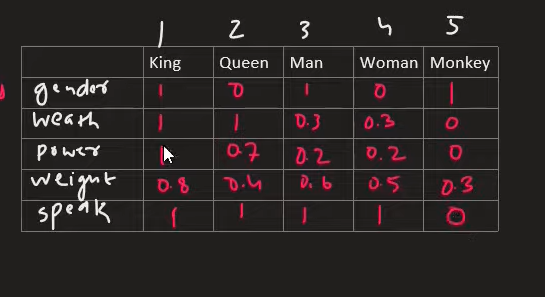

so if i want to represent king,
the vector would be [1,1,1,0.8,1],
monkey would be represented as [1,0,0,0.3,0]

so basically, word to vec creates features depending on the vocabulary,and assign values aginst those words
since these are vectors, we can  do something like, king-man+women that will give us something closer to women

king - man + woman  

for gender -> 1 - 1 + 0 = 0  
for wealth -> 1 - 0.3 + 0.3 = 1  
for power -> 1 - 0.2 + 0.2 = 1  
for weight -> 0.8 - 0.6 + 0.5 = 0.7  
for speak -> 1 - 1 + 1 = 1  

and if we see the resultant vector => [0, 1, 1, 0.7, 1], it comes very close to queen.

the main problem, in real world, the number of vocabulary will be in lakhs, in our case we had only 5. it wouldn't be possible to handcraft features. so in order to do that we need some automated technique, and this is where neural network comes in hand  

the downside is that we wouldn't know what those features are, we will only know the values

now we know that using word2vec, deep learning will create the features, but how it decides what those features will be? the core logic to decide that, that the word2vec follows is

The underlying assumption of Word2Vec is that two words sharing similar contexts also share a similar meaning and consequently a similar vector representation from the model.

types of word2vec  

word2vec has two architectures:  
-> cbow

-> skip-gram

refer to : https://www.baeldung.com/cs/word-embeddings-cbow-vs-skip-gram

| Feature                      | CBOW (Continuous Bag of Words)                 | Skip-gram                                       |
| ---------------------------- | ---------------------------------------------- | ----------------------------------------------- |
| **Goal**                     | Predict **target word** from **context words** | Predict **context words** from **target word**  |
| **Input**                    | Multiple context words                         | Single target word                              |
| **Output**                   | Target word                                    | Multiple context words                          |
| **Training Data Efficiency** | Faster, good for **large datasets**            | Slower, better for **small datasets**           |
| **Performance**              | Works well for **frequent words**              | Works well for **rare words**                   |
| **Use Case**                 | General embedding generation, large corpora    | Capturing rare word relationships, small corpus |


Which One Is Better?

Large corpus & frequent words → CBOW (faster, less data needed per word)


Small corpus or rare words → Skip-gram (better representation for rare words)

# Improving Word2Vec Embeddings

- **More training data** → better coverage, especially for rare words  
- **Higher vector dimension** → captures more semantic meaning (but uses more memory)  
- **Larger window size** → captures broader context; smaller window captures syntax  
